Mounted at /content/drive


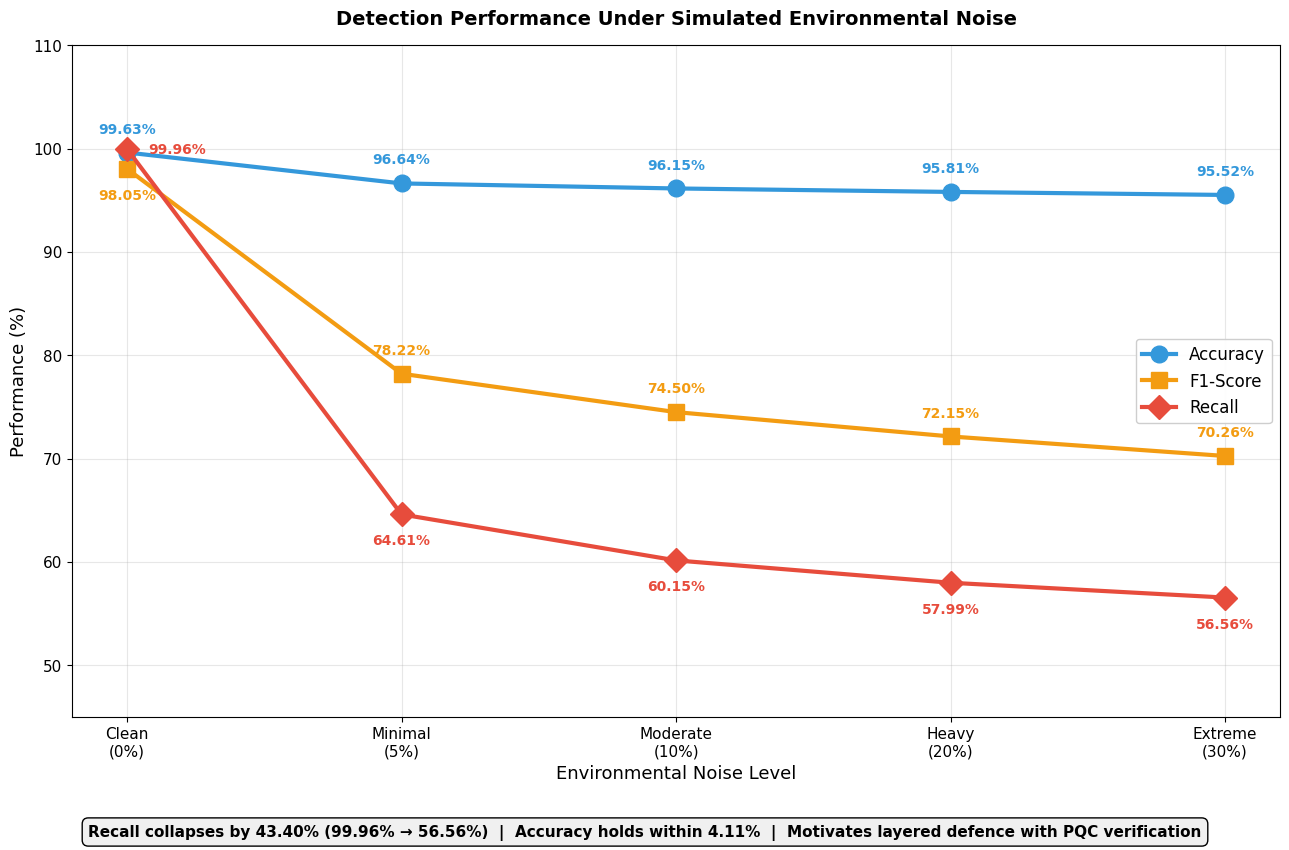

Saved: figure_noise_github.png


In [1]:
# ============================================================
# Figure B.2: Noise Resilience Test (v2 - cleaner labels)
# GitHub version (with title)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import numpy as np

ACCURACY_COLOR = "#3498db"
F1_COLOR = "#f39c12"
RECALL_COLOR = "#e74c3c"

noise_labels = ["Clean\n(0%)", "Minimal\n(5%)", "Moderate\n(10%)",
                "Heavy\n(20%)", "Extreme\n(30%)"]
accuracies = [99.6277, 96.6353, 96.1496, 95.814, 95.522]
recalls = [99.9626, 64.6064, 60.1536, 57.9915, 56.5578]
f1_scores = [98.0476, 78.2207, 74.504, 72.15, 70.26]

fig, ax = plt.subplots(figsize=(13, 8.5))
x = np.arange(len(noise_labels))

ax.plot(x, accuracies, color=ACCURACY_COLOR, marker='o', markersize=12,
        linewidth=3, label="Accuracy")
ax.plot(x, f1_scores, color=F1_COLOR, marker='s', markersize=12,
        linewidth=3, label="F1-Score")
ax.plot(x, recalls, color=RECALL_COLOR, marker='D', markersize=12,
        linewidth=3, label="Recall")

ax.set_xlabel("Environmental Noise Level", fontsize=13)
ax.set_ylabel("Performance (%)", fontsize=13)
ax.set_title("Detection Performance Under Simulated Environmental Noise",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(noise_labels, fontsize=11)
ax.set_ylim(45, 110)
ax.grid(axis="both", alpha=0.3)
ax.legend(loc="center right", fontsize=12, framealpha=0.95)
ax.tick_params(axis='y', labelsize=11)

for i, (acc, rec, f1) in enumerate(zip(accuracies, recalls, f1_scores)):
    ax.annotate(f"{acc:.2f}%",
                xy=(i, acc), xytext=(0, 14),
                textcoords="offset points", ha="center",
                fontsize=10, fontweight="bold", color=ACCURACY_COLOR)

    if i == 0:
        ax.annotate(f"{f1:.2f}%",
                    xy=(i, f1), xytext=(0, -22),
                    textcoords="offset points", ha="center",
                    fontsize=10, fontweight="bold", color=F1_COLOR)
    else:
        ax.annotate(f"{f1:.2f}%",
                    xy=(i, f1), xytext=(0, 14),
                    textcoords="offset points", ha="center",
                    fontsize=10, fontweight="bold", color=F1_COLOR)

    if i == 0:
        ax.annotate(f"{rec:.2f}%",
                    xy=(i, rec), xytext=(15, 0),
                    textcoords="offset points", ha="left", va="center",
                    fontsize=10, fontweight="bold", color=RECALL_COLOR)
    else:
        ax.annotate(f"{rec:.2f}%",
                    xy=(i, rec), xytext=(0, -22),
                    textcoords="offset points", ha="center",
                    fontsize=10, fontweight="bold", color=RECALL_COLOR)

recall_drop = recalls[0] - recalls[-1]
accuracy_drop = accuracies[0] - accuracies[-1]
fig.text(0.5, 0.01,
         f"Recall collapses by {recall_drop:.2f}% (99.96% → 56.56%)  |  "
         f"Accuracy holds within {accuracy_drop:.2f}%  |  "
         f"Motivates layered defence with PQC verification",
         ha="center", fontsize=11, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="black"))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("/content/drive/MyDrive/veremi_thesis/figure_noise_github.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure_noise_github.png")